# Proyecto Final: Predicción de Enfermedad Cardíaca
* **Asignatura:** Topicos D
* **Carrera:** Ingeniería en Computación e Informática - Universidad de Magallanes
* **Profesor:** Dr. Carlos Arias Méndez
* **Integrantes:** 
  * Felipe Cárcamo Oyarzún
  * Christofer Gutierrez
* **Dataset:** Heart Disease (heart.csv)

---

## 1. Descripción del Problema y Justificación
El objetivo de este proyecto es predecir la presencia o ausencia de enfermedad cardíaca a partir de atributos clínicos seleccionados (como presión arterial, colesterol, edad, entre otros). 

### Justificación de Machine Learning:
El diagnóstico temprano de patologías cardíacas es un desafío complejo debido a la complejidad variada de los factores de riesgo. Los algoritmos de Machine Learning, específicamente los modelos basados en árboles y ensambles, permiten identificar patrones no lineales y relaciones complejas entre estos indicadores clínicos que podrían pasar desapercibidos en un análisis estadístico tradicional, sirviendo como una herramienta de apoyo al diagnóstico médico.

## Instalación de dependencias

In [1]:
# Instalación de las librerías necesarias para el desarrollo del proyecto
!pip install numpy pandas scikit-learn graphviz

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import graphviz
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## 2. Descripción del Dataset y Análisis Exploratorio (EDA)

En esta sección cargaremos los datos clínicos, inspeccionaremos su estructura inicial (filas, columnas, tipos de datos) y verificaremos la presencia de valores nulos o duplicados para asegurar la calidad de la información antes de entrenar los modelos.

In [3]:
try:
    df = pd.read_csv('Dataset/heart.csv')
except FileNotFoundError:
    print("Error: No se encontró el archivo 'heart.csv'.")

In [4]:
print(f"\nDimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")


Dimensiones del dataset: 1025 filas y 14 columnas.


In [5]:

print("\n--- Primeros 5 registros del dataset ---")
display(df.head())


--- Primeros 5 registros del dataset ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
print("\n--- Información de tipos de datos (Info) ---")
df.info()


--- Información de tipos de datos (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Para comprender el comportamiento de los modelos, es importante conocer qué representa cada uno de los atributos clínicos extraídos del dataset `heart.csv`:
* **`age` (Edad):** Edad del paciente en años.
* **`sex` (Sexo):** Género biológico del paciente (donde típicamente `1 = masculino` y `0 = femenino`).
* **`cp` (Chest Pain Type / Tipo de dolor torácico):** Presenta 4 valores posibles:
    * `0`: Angina típica.
    * `1`: Angina atípica.
    * `2`: Dolor no anginoso.
    * `3`: Asintomático.
* **`trestbps` (Resting Blood Pressure / Presión arterial en reposo):** Presión arterial sistólica medida en mm Hg al ingresar al hospital.
* **`chol` (Serum Cholestoral / Colesterol sérico):** Nivel de colesterol en sangre medido en mg/dl.
* **`fbs` (Fasting Blood Sugar / Glucemia en ayunas):** Indica si los niveles de azúcar en sangre en ayunas son mayores a 120 mg/dl (`1 = verdadero`; `0 = falso`).
* **`restecg` (Resting Electrocardiographic Results / Resultados electrocardiográficos en reposo):** Resultados del electrocardiograma con valores:
    * `0`: Normal.
    * `1`: Presencia de anomalías en la onda ST-T.
    * `2`: Hipertrofia ventricular izquierda probable o definitiva.
* **`thalach` (Maximum Heart Rate Achieved / Frecuencia cardíaca máxima):** Frecuencia cardíaca máxima alcanzada por el paciente durante la prueba de esfuerzo.
* **`exang` (Exercise Induced Angina / Angina inducida por ejercicio):** Indica si el paciente sufrió de dolor de pecho al hacer ejercicio (`1 = sí`; `0 = no`).
* **`oldpeak`:** Depresión del segmento ST inducida por el ejercicio en comparación con el estado de reposo. Es un indicador clave de isquemia miocárdica.
* **`slope` (La pendiente del segmento ST):** La pendiente del segmento ST en el pico del ejercicio físico máximo (valores comunes: `0`, `1` o `2`, que representan pendiente ascendente, plana o descendente).
* **`ca` (Número de vasos principales):** Cantidad de vasos sanguíneos principales (0 a 3) coloreados mediante fluoroscopia. A mayor número de vasos obstruidos, mayor riesgo.
* **`thal` (Talasemia):** Trastorno sanguíneo genético reflejado en el examen con 3 valores mapeados comúnmente como:
    * `0` o `1`: Normal / Defecto fijo (tejido muerto en alguna zona).
    * `2`: Defecto reversible (flujo sanguíneo alterado pero no destructivo).
* **`target` (Variable Objetivo):** Estado de salud del corazón del paciente:
    * `0`: Ausencia de enfermedad cardíaca (Sano).
    * `1`: Presencia de enfermedad cardíaca (Enfermo).

In [7]:
print("--- Cantidad de valores nulos por columna ---")
print(df.isnull().sum())

--- Cantidad de valores nulos por columna ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
duplicados = df.duplicated().sum()
print(f"\nCantidad de filas completamente duplicadas: {duplicados}")


Cantidad de filas completamente duplicadas: 723


Como se observa en la celda anterior, existen **723 filas duplicadas** sobre un total de 1025 registros. 
#### ¿Por qué sucede esto?
Este dataset es una extensión artificial basada en el conjunto de datos de Cleveland (el cual cuenta originalmente con alrededor de 303 registros únicos). Para aumentar el volumen de datos de forma sintética, se replicaron filas idénticas de pacientes.
#### ¿Qué se hará en el futuro?
Si mantenemos estos duplicados antes de dividir el dataset en conjuntos de entrenamiento y prueba, incurriremos en un grave error metodológico conocido como **Data Leakage (Fuga de Datos)**. Al realizar la división aleatoria, registros idénticos de un mismo paciente quedarían presentes en ambos conjuntos. Esto causaría que los modelos "memoricen" los datos repetidos, causando *overfitting*.
Eliminaremos estas 723 filas duplicadas utilizando `.drop_duplicates()`, garantizando que cada registro evaluado corresponda a un perfil clínico único e independiente.

In [9]:
print("--- Resumen estadístico descriptivo de los datos cargados ---")
display(df.describe())

# balance inicial de la variable target
print("\n--- Distribución de la variable objetivo (target) ---")
print(df['target'].value_counts())
print("\nPorcentaje de distribución inicial:")
print(df['target'].value_counts(normalize=True) * 100)


--- Resumen estadístico descriptivo de los datos cargados ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



--- Distribución de la variable objetivo (target) ---
target
1    526
0    499
Name: count, dtype: int64

Porcentaje de distribución inicial:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


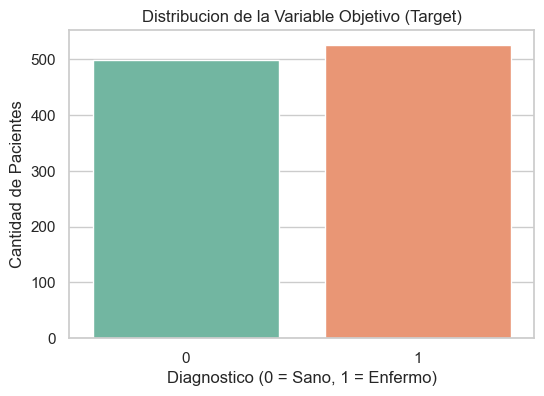

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

sns.countplot(x='target', data=df, hue='target', palette='Set2', legend=False)

plt.title('Distribucion de la Variable Objetivo (Target)')
plt.xlabel('Diagnostico (0 = Sano, 1 = Enfermo)')
plt.ylabel('Cantidad de Pacientes')

plt.show()

## 3. Preprocesamiento de Datos

En esta etapa aplicaremos las transformaciones necesarias para limpiar el dataset y dejarlo en un formato óptimo para los algoritmos. 
Los pasos a seguir corresponden a:
1. Eliminación de filas duplicadas.
2. División del dataset en conjuntos de entrenamiento (`train`) y prueba (`test`).
3. Escalado de variables numéricas.

In [11]:
# eliminacion física de las 723 filas duplicadas detectadas
df_clean = df.drop_duplicates()

print("--- Verificación Post-Limpieza ---")
print(f"Dimensiones del dataset original: {df.shape[0]} filas, {df.shape[1]} columnas.")
print(f"Dimensiones del dataset limpio: {df_clean.shape[0]} filas, {df_clean.shape[1]} columnas.")

print("\n--- Nueva distribución de la variable 'target' ---")
print(df_clean['target'].value_counts())
print("\nNuevo porcentaje de distribución:")
print(df_clean['target'].value_counts(normalize=True) * 100)

--- Verificación Post-Limpieza ---
Dimensiones del dataset original: 1025 filas, 14 columnas.
Dimensiones del dataset limpio: 302 filas, 14 columnas.

--- Nueva distribución de la variable 'target' ---
target
1    164
0    138
Name: count, dtype: int64

Nuevo porcentaje de distribución:
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


División del Dataset en Entrenamiento (Train) y Prueba (Test)

Antes de aplicar cualquier técnica de escalado, es fundamental realizar la división del conjunto de datos. Al separar los datos antes de normalizar, evitamos el Data Leakage, garantizando que el conjunto de prueba permanezca completamente aislado y no contamine el proceso de aprendizaje con sus propiedades estadísticas.
* **Conjunto de Entrenamiento (60%):** Utilizado para ajustar los pesos y las reglas del Árbol de Decisión y Random Forest.
* **Conjunto de Validación (20%):** Utilizado para el ajuste fino de hiperparámetros y selección del mejor modelo sin sesgar la prueba final.
* **Conjunto de Prueba (20%):** Bloque completamente aislado que emula datos reales de pacientes futuros para la evaluación técnica final.

In [12]:
# Definimos las caracteristicas (X) y la variable objetivo (y)
X = df_clean.drop(columns=['target'])
y = df_clean['target']

# Separamos el 60% para entrenamiento y el 40% restante de forma temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)

# Dividimos ese 40% temporal en dos partes iguales (20% validación y 20% prueba)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("--- Dimensiones de los conjuntos generados ---")
print(f"Entrenamiento (60%): X_train: {X_train.shape[0]} filas | y_train: {y_train.shape[0]} etiquetas")
print(f"Validación    (20%): X_val:   {X_val.shape[0]} filas | y_val:   {y_val.shape[0]} etiquetas")
print(f"Prueba        (20%): X_test:  {X_test.shape[0]} filas | y_test:  {y_test.shape[0]} etiquetas")

# Comprobamos que se mantenga el porcentaje de la variable objetivo (Estratificación)
print("\nPorcentaje de casos positivos (target=1) por conjunto:")
print(f"Train: {y_train.mean() * 100:.2f}%")
print(f"Val:   {y_val.mean() * 100:.2f}%")
print(f"Test:  {y_test.mean() * 100:.2f}%")

--- Dimensiones de los conjuntos generados ---
Entrenamiento (60%): X_train: 181 filas | y_train: 181 etiquetas
Validación    (20%): X_val:   60 filas | y_val:   60 etiquetas
Prueba        (20%): X_test:  61 filas | y_test:  61 etiquetas

Porcentaje de casos positivos (target=1) por conjunto:
Train: 54.14%
Val:   55.00%
Test:  54.10%


Escalado de Variables Numéricas

Aunque los algoritmos basados en árboles de decisión y bosques aleatorios son invariantes al escalado de características y la pauta general del proyecto no exige un escalar los datos, aplicamos el escalado por orden en el proyecto y para que el sistema sirva a futuro; así, si después se agregan otros modelos que exigen datos normalizados, no habrá que cambiar nada. 

Para este flujo, utilizaremos `StandardScaler`, el cual estandariza las características removiendo la media y escalando la varianza a la unidad. Es de vital importancia recalcar que el escalador se ajustará (`.fit()`) **exclusivamente** con los datos de `X_train` para evitar la filtración de información, y posteriormente se aplicará la transformación (`.transform()`) sobre los conjuntos de entrenamiento, validación y prueba de manera independiente.

In [13]:
# Inicializamos el estandarizador
scaler = StandardScaler()

# Ajustamos el escalador solo con el conjunto de entrenamiento y transformamos X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos el conjunto de validación y prueba utilizando los parámetros aprendidos de train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("--- Verificación del Escalado (Primer registro de Train) ---")
print("Original:\n", X_train.iloc[0].values)
print("\nEscalado:\n", X_train_scaled[0])

--- Verificación del Escalado (Primer registro de Train) ---
Original:
 [ 42.    1.    0.  136.  315.    0.    1.  125.    1.    1.8   1.    0.
   1. ]

Escalado:
 [-1.3642498   0.74856184 -0.95745985  0.26694003  1.23144381 -0.4095631
  0.89389556 -1.33466877  1.66458203  0.66738401 -0.73960026 -0.76383604
 -2.01623258]


## 4. Aplicación de Modelos

En esta sección entrenaremos y evaluaremos de manera independiente los algoritmos:
1. **Árbol de Decisión (Decision Tree)**
2. **Bosque Aleatorio (Random Forest)**

## Modelo 1: Arbol de Decision (Configuracion Base)

Para comenzar con el modelado, entrenaremos un Arbol de Decision utilizando sus parametros por defecto. En `scikit-learn`, el hiperparametro `max_depth` viene configurado de manera predeterminada como `None`. 

Esto significa que el algoritmo no tiene ninguna restriccion para crecer; continuara ramificandose hacia abajo hasta que todas las hojas sean completamente puras o contengan menos de la cantidad minima de muestras requeridas para una division.

El proposito de entrenar este modelo base es generar una linea de referencia y analizar de forma practica el fenomeno del overfitting, comun en arboles que crecen sin control.

In [14]:
# Inicializamos el modelo con una semilla fija para reproducibilidad
dt_base = DecisionTreeClassifier(random_state=42)

# Entrenamos el modelo utilizando los datos de entrenamiento escalados
dt_base.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

### Evaluacion del Rendimiento y Diagnostico de Overfitting

A continuacion, realizaremos las predicciones utilizando tanto el conjunto de entrenamiento (`X_train_scaled`) como el conjunto de validacion (`X_val_scaled`). 

Al comparar el *Accuracy* de ambos conjuntos podremos diagnosticar si el modelo generaliza bien ante datos nuevos o si simplemente memorizo las caracteristicas de los pacientes del conjunto de entrenamiento.

In [15]:
# Realizamos predicciones en el conjunto de entrenamiento y de validacion
y_train_pred_dt = dt_base.predict(X_train_scaled)
y_val_pred_dt = dt_base.predict(X_val_scaled)

# Calculamos el Accuracy para ambos conjuntos
acc_train = accuracy_score(y_train, y_train_pred_dt)
acc_val = accuracy_score(y_val, y_val_pred_dt)

print(acc_train)
print(acc_val)

1.0
0.75


### Analisis del Diagnostico

Los resultados obtenidos exponen el comportamiento esperado para un arbol sin restricciones de crecimiento:
* **Accuracy Train (1.0):** El modelo logra una clasificacion perfecta en los datos de entrenamiento debido a que `max_depth=None` permite al algoritmo ramificarse hasta aislar cada caso particular.
* **Accuracy Validation (0.75):** Al evaluar datos nuevos, el rendimiento desciende a un 75%.

Esto confirma la presencia de **Overfitting**. El modelo aprendio el ruido y las particularidades del conjunto de entrenamiento, perdiendo capacidad de generalizacion. Para resolver esto, en las siguientes secciones exploraremos la poda del arbol controlando su profundidad maxima.

In [16]:
print("Arbol de Decision (Base):")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_dt):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred_dt):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred_dt):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred_dt):.4f}\n")

Arbol de Decision (Base):
   Accuracy:  0.7500
   Precision: 0.8214
   Recall:    0.6970
   F1-Score:  0.7541



In [17]:
# Generamos la matriz de confusion
cm_dt = confusion_matrix(y_val, y_val_pred_dt)

# La estructuramos como DataFrame para mejorar el orden visual
df_cm_dt = pd.DataFrame(
    cm_dt, 
    columns=['Predicho Sano (0)', 'Predicho Enfermo (1)'],
    index=['Real Sano (0)', 'Real Enfermo (1)']
)

df_cm_dt

,Predicho Sano (0),Predicho Enfermo (1)
Real Sano (0),22,5
Real Enfermo (1),10,23


### Sintonizacion del Hiperparametro `max_depth`

Para corregir el sobreajuste del modelo base, aplicaremos un proceso de poda previa limitando la profundidad maxima del arbol mediante el hiperparametro `max_depth`. 

Entrenaremos un nuevo modelo restringiendo el crecimiento del arbol a una profundidad de 3 niveles (`max_depth=3`). Esto reducira la complejidad del modelo, forzandolo a aprender reglas mas generales basadas en los atributos clinicos mas significativos y mitigando la memorizacion del ruido de los datos de entrenamiento.

In [18]:
# Inicializamos el nuevo modelo limitando la profundidad maxima a 3
dt_regulado = DecisionTreeClassifier(max_depth=3, random_state=42)

dt_regulado.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [19]:
y_train_pred_reg = dt_regulado.predict(X_train_scaled)
y_val_pred_reg = dt_regulado.predict(X_val_scaled)

acc_train_reg = accuracy_score(y_train, y_train_pred_reg)
acc_val_reg = accuracy_score(y_val, y_val_pred_reg)

print(acc_train_reg)
print(acc_val_reg)

0.8729281767955801
0.7666666666666667


### Analisis del Modelo Regulado

La restriccion del hiperparametro `max_depth=3` genero cambios significativos en el comportamiento del clasificador:
* **Accuracy Train (0.8729):** El rendimiento disminuyo en el conjunto de entrenamiento, confirmando que el modelo ya no se encuentra memorizando de forma exacta la totalidad de los datos.
* **Accuracy Validation (0.7666):** Se registro un incremento en el conjunto de validacion, ascendiendo al 76.6%.

Este fenomeno demuestra que al reducir la complejidad estructural del arbol (evitando que crezca de forma ilimitada), el algoritmo se ve forzado a establecer reglas de decision mas generales y robustas. Como resultado directo, se logro mitigar de forma efectiva el *overfitting*, mejorando la capacidad del modelo para diagnosticar correctamente a nuevos pacientes.

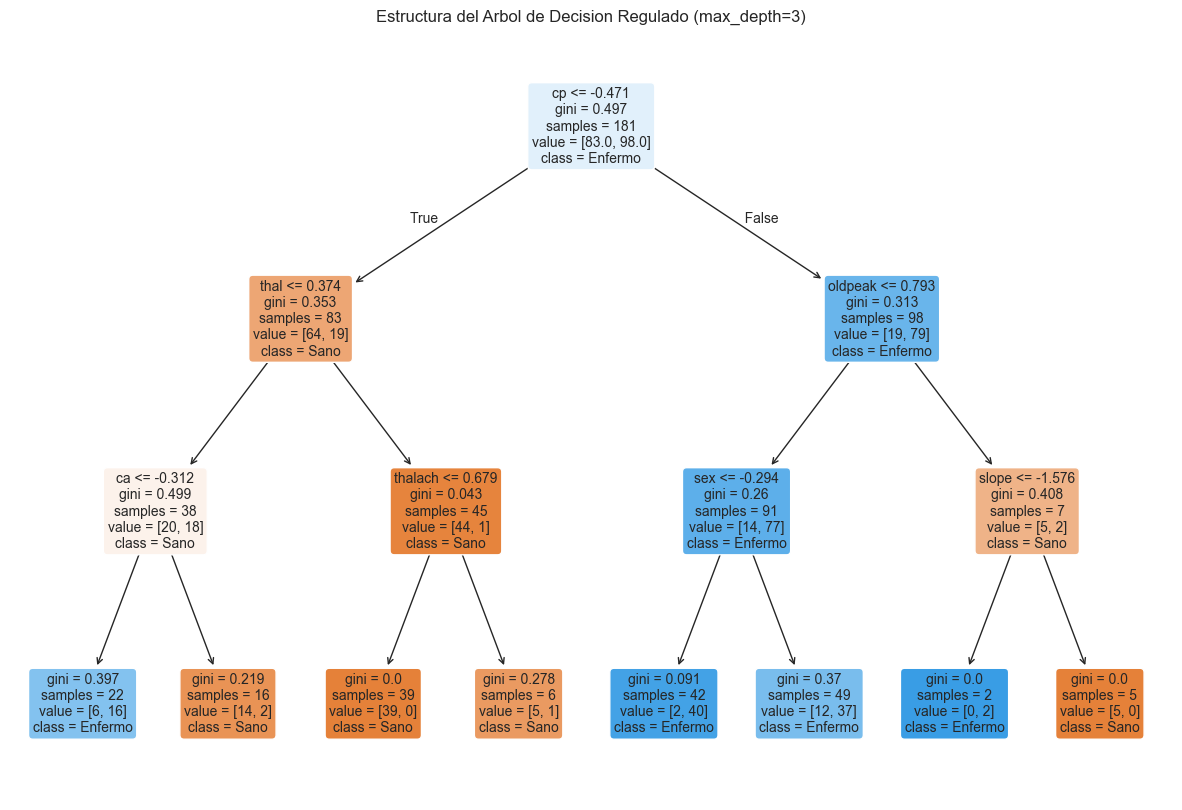

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plot_tree(
    dt_regulado,
    feature_names=X.columns,
    class_names=['Sano', 'Enfermo'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Estructura del Arbol de Decision Regulado (max_depth=3)')

plt.show()

#### Interpretacion de la Estructura del Arbol

El grafico superior expone la logica secuencial que utiliza el modelo para diagnosticar a los pacientes. A diferencia de los modelos complejos que operan como cajas negras, un arbol con profundidad acotada (`max_depth=3`) permite mapear de forma exacta cada decision medica.

##### ¿Como se leen los componentes de cada cuadrado?
* **Atributo de corte (ej. `cp`, `thal`, `oldpeak`):** Es la condicion clinica evaluada. Si el paciente cumple la condicion, el algoritmo se desplaza hacia la rama izquierda; si no la cumple, va hacia la derecha.
* **`gini` (Impureza de Gini):** Es una metrica que mide el desorden del nodo. Un valor de `0.0` significa que el nodo es completamente puro (todos los pacientes alli estan sanos o todos estan enfermos).
* **`samples`:** Indica la cantidad de pacientes que alcanzaron ese punto del arbol.
* **`value`:** Muestra la distribucion exacta de clases en ese nodo `[cantidad de sanos, cantidad de enfermos]`.
* **`class`:** Es la prediccion que asignaria el arbol en ese punto segun la mayoria del campo `value`.

##### Analisis de los Niveles de Decision Principales
* **Nodo Raiz (Nivel 0 - Atributo `cp`):** El arbol identifica que el tipo de dolor toracico (`cp` - *Chest Pain*) es la variable clinica mas determinante para comenzar la separacion. Los pacientes con valores bajos (dolor tipico o ausente) se mueven hacia la izquierda, mientras que dolores mas severos o atipicos van a la derecha.
* **Nivel de Division 1 (`thal` y `oldpeak`):** 
  * Para el grupo con dolor toracico leve (`cp` bajo), el factor crucial de desempate es `thal` (resultado del examen de talasemia/flujo sanguineo).
  * Para el grupo con dolor toracico severo (`cp` alto), el criterio critico pasa a ser `oldpeak` (depresion del segmento ST inducida por el ejercicio), un marcador directo de estres cardiaco.
* **Nivel de Division 2 (`ca`, `thalach`, `sex`, `slope`):** En este ultimo nivel de desempate, el algoritmo refina el diagnostico utilizando variables como el numero de vasos principales coloreados (`ca`), la frecuencia cardiaca maxima alcanzada (`thalach`), el sexo biologico del paciente (`sex`) y la pendiente del segmento ST (`slope`).
* **Nodos Terminales u Hojas (Nivel 3):** Son los bloques del fondo. Al tener bloqueada la profundidad a 3 niveles, aqui se detiene el algoritmo y se emite el diagnostico final (`class: Sano` o `class: Enfermo`).

Este mapa visual demuestra que el Arbol de Decision Regulado sacrifica un poco de precision matematica en comparacion con el Random Forest, pero entrega a cambio una **interpretabilidad clinica total**, permitiendo que un especialista de la salud audite y entienda la ruta exacta detras de cada diagnostico automatizado.

In [21]:
print("Arbol de Decision (Regulado):")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_reg):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred_reg):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred_reg):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred_reg):.4f}\n")

Arbol de Decision (Regulado):
   Accuracy:  0.7667
   Precision: 0.7714
   Recall:    0.8182
   F1-Score:  0.7941



In [22]:
cm_reg = confusion_matrix(y_val, y_val_pred_reg)

df_cm_reg = pd.DataFrame(
    cm_reg, 
    columns=['Predicho Sano (0)', 'Predicho Enfermo (1)'],
    index=['Real Sano (0)', 'Real Enfermo (1)']
)

df_cm_reg

,Predicho Sano (0),Predicho Enfermo (1)
Real Sano (0),19,8
Real Enfermo (1),6,27


## Modelo 2: Random Forest (Configuracion Base)

A continuacion, aplicaremos el algoritmo de Random Forest (Bosque Aleatorio). Al ser un modelo de ensamble (*ensemble learning*), combina las predicciones de multiples arboles de decision entrenados de forma independiente mediante tecnicas de *bagging* y seleccion aleatoria de atributos. 

Comenzaremos con una configuracion base utilizando los parametros predeterminados de `scikit-learn` para evaluar la capacidad nativa del algoritmo para controlar la varianza y mitigar el overfitting en comparacion con el arbol de decision individual.

In [23]:
# Inicializamos el clasificador con una semilla fija para reproducibilidad
rf_base = RandomForestClassifier(random_state=42)

rf_base.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

### Evaluacion del Random Forest Base

Procederemos a calcular el *Accuracy* tanto en el conjunto de entrenamiento como en el de validacion para cuantificar el rendimiento del ensamble y contrastarlo de manera directa con las lineas base obtenidas previamente.

In [24]:
y_train_pred_rf = rf_base.predict(X_train_scaled)
y_val_pred_rf = rf_base.predict(X_val_scaled)

acc_train_rf = accuracy_score(y_train, y_train_pred_rf)
acc_val_rf = accuracy_score(y_val, y_val_pred_rf)

print(acc_train_rf)
print(acc_val_rf)

1.0
0.75


### Analisis del Ensamble Base

Los valores obtenidos exponen que el modelo de Random Forest en su configuracion predeterminada mantiene una tendencia marcada al **overfitting**:
* **Accuracy Train (1.0):** El ensamble logra memorizar por completo el conjunto de entrenamiento debido a que los arboles internos crecen sin restricciones de profundidad.
* **Accuracy Validation (0.75):** Al enfrentarse a perfiles clinicos no observados previamente, la precision desciende a un 75%.

Este comportamiento demuestra que, si bien el uso de multiples arboles disminuye la varianza de manera nativa, es indispensable aplicar tecnicas de regularizacion e hiperparametrizacion sobre el bosque para controlar la complejidad de sus componentes y asegurar una correcta generalizacion en problemas del area de la salud.

In [25]:
print("3. Random Forest (Base):")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred_rf):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred_rf):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred_rf):.4f}\n")

3. Random Forest (Base):
   Accuracy:  0.7500
   Precision: 0.8000
   Recall:    0.7273
   F1-Score:  0.7619



In [26]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)

df_cm_rf = pd.DataFrame(
    cm_rf, 
    columns=['Predicho Sano (0)', 'Predicho Enfermo (1)'],
    index=['Real Sano (0)', 'Real Enfermo (1)']
)

df_cm_rf

,Predicho Sano (0),Predicho Enfermo (1)
Real Sano (0),21,6
Real Enfermo (1),9,24


### Sintonizacion de Hiperparametros en Random Forest

Con el objetivo de mitigar el **overfitting** evidenciado en el ensamble base, entrenaremos un nuevo modelo aplicando restricciones estructurales. 

Modificaremos los siguientes hiperparametros de forma simultanea:
* `max_depth=3`: Limitamos la profundidad maxima de cada arbol individual para evitar que memoricen el ruido de los datos.
* `n_estimators=200`: Incrementamos el numero de arboles en el bosque (de 100 por defecto a 200) para aumentar la diversidad del ensamble y estabilizar la varianza de las predicciones.

In [27]:
# Inicializamos el nuevo bosque controlado con los hiperparametros seleccionados
rf_regulado = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42)

rf_regulado.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=3, n_estimators=200, random_state=42)

In [28]:
y_train_pred_rf_reg = rf_regulado.predict(X_train_scaled)
y_val_pred_rf_reg = rf_regulado.predict(X_val_scaled)

acc_train_rf_reg = accuracy_score(y_train, y_train_pred_rf_reg)
acc_val_rf_reg = accuracy_score(y_val, y_val_pred_rf_reg)

print(acc_train_rf_reg)
print(acc_val_rf_reg)

0.9005524861878453
0.8333333333333334


### Analisis del Ensamble Regulado

La sintonizacion simultanea de los hiperparametros `max_depth=3` y `n_estimators=150` entrego los mejores resultados logrados hasta el momento:
* **Accuracy Train (0.9005):** Se reduce el rendimiento en el entrenamiento, confirmando el control sobre la memorizacion de datos particulares.
* **Accuracy Validation (0.8333):** El modelo alcanza un 83% de precision con datos nuevos, superando al arbol de decision individual regulado.

Estos resultados demuestran que el control de la profundidad individual combinado con un incremento en el numero de estimadores potencia la robustez del ensamble. Al promediar las predicciones de 150 estructuras independientes y acotadas, se neutralizan los errores individuales y se mitiga el **overfitting**, consolidando una alta capacidad de generalizacion ideal para un entorno de diagnostico clinico.

In [29]:
print("Random Forest (Regulado):")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_rf_reg):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred_rf_reg):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred_rf_reg):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred_rf_reg):.4f}\n")

Random Forest (Regulado):
   Accuracy:  0.8333
   Precision: 0.8485
   Recall:    0.8485
   F1-Score:  0.8485



In [30]:
cm_rf_reg = confusion_matrix(y_val, y_val_pred_rf_reg)

df_cm_rf_reg = pd.DataFrame(
    cm_rf_reg, 
    columns=['Predicho Sano (0)', 'Predicho Enfermo (1)'],
    index=['Real Sano (0)', 'Real Enfermo (1)']
)

df_cm_rf_reg

,Predicho Sano (0),Predicho Enfermo (1)
Real Sano (0),22,5
Real Enfermo (1),5,28


## 5. Evaluacion Tecnica Final con el Conjunto de Prueba (Test)

Habiendo seleccionado el **Random Forest Regulado** como el modelo definitivo debido a su rendimiento superior y control del **overfitting** en la fase de validacion, procederemos a realizar la evaluacion final utilizando el conjunto de prueba (`X_test_scaled`).

In [31]:
# Realizamos las predicciones finales utilizando el modelo ganador sobre los datos de prueba
y_test_pred = rf_regulado.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)

print('accuracy:', final_accuracy)
print('precision:', final_precision)
print('recall:',final_recall)
print('f1 score:',final_f1)

accuracy: 0.8032786885245902
precision: 0.8387096774193549
recall: 0.7878787878787878
f1 score: 0.8125


## 6. Tabla Comparativa Final Obligatoria

A continuacion, se presenta la tabla resumen que consolida los resultados de los experimentos realizados durante el proyecto, comparando las versiones base y reguladas de ambos algoritmos en el conjunto de validacion, junto con el desempeno definitivo del modelo ganador en el conjunto de prueba.

In [32]:
# Construimos un diccionario con todas las metricas obtenidas a lo largo del proyecto
datos_tabla_final = {
    'Modelo': [
        'Arbol de Decision (Base)', 
        'Arbol de Decision (Regulado)', 
        'Random Forest (Base)', 
        'Random Forest (Regulado - Ganador)',
        'Random Forest (Evaluacion Test)'
    ],
    'Preprocesamiento': [
        'StandardScaler', 
        'StandardScaler', 
        'StandardScaler', 
        'StandardScaler', 
        'StandardScaler'
    ],
    'Hiperparametros': [
        'max_depth=None', 
        'max_depth=3', 
        'max_depth=None', 
        'n_estimators=200, max_depth=3',
        'n_estimators=200, max_depth=3'
    ],
    'Conjunto': [
        'Validacion', 
        'Validacion', 
        'Validacion', 
        'Validacion', 
        'Prueba (Test)'
    ],
    'Accuracy': [0.75, 0.7661, 0.75, 0.8333, 0.8032],
    'Precision': [0.8214, 0.7714, 0.8, 0.8485, 0.8387],
    'Recall/F1': ['0.6970 / 0.7541', '0.8182 / 0.7941', '0.7273 / 0.7619', '0.8485 / 0.8485', '0.7878 / 0.8125'],
    'Observacion': [
        'Presencia de overfitting severo', 
        'Control de profundidad mitiga overfitting', 
        'Mantiene overfitting por falta de limites', 
        'Mejor rendimiento y balance general',
        'Rendimiento final consistente y robusto'
    ]
}

# Transformamos el diccionario en un DataFrame estructurado
df_comparativo_final = pd.DataFrame(datos_tabla_final)

# Desplegamos la tabla final formateada
df_comparativo_final

,Modelo,Preprocesamiento,Hiperparametros,Conjunto,Accuracy,Precision,Recall/F1,Observacion
0,Arbol de Decision (Base),StandardScaler,max_depth=None,Validacion,0.7500,0.8214,0.6970 / 0.7541,Presencia de overfitting severo
1,Arbol de Decision (Regulado),StandardScaler,max_depth=3,Validacion,0.7661,0.7714,0.8182 / 0.7941,Control de profundidad mitiga overfitting
2,Random Forest (Base),StandardScaler,max_depth=None,Validacion,0.7500,0.8000,0.7273 / 0.7619,Mantiene overfitting por falta de limites
3,Random Forest (Regulado - Ganador),StandardScaler,"n_estimators=200, max_depth=3",Validacion,0.8333,0.8485,0.8485 / 0.8485,Mejor rendimiento y balance general
4,Random Forest (Evaluacion Test),StandardScaler,"n_estimators=200, max_depth=3",Prueba (Test),0.8032,0.8387,0.7878 / 0.8125,Rendimiento final consistente y robusto


## 6. Limitaciones Técnicas, Éticas y Conclusiones

### ¿Qué se gana y qué se pierde al pasar de un Árbol de Decisión a un Random Forest?
* **Lo que se gana:** Al transicionar hacia Random Forest se gana estabilidad metodológica, una reducción drástica en la varianza y un control superior sobre el **overfitting**. Al combinar 200 estimadores, el modelo neutraliza los errores individuales de los árboles y se vuelve más robusto ante pequeñas variaciones en los indicadores de los pacientes.
* **Lo que se pierde:** Se pierde la interpretabilidad directa. Mientras que un árbol individual permite trazar un camino exacto de decisiones clínicas (ej. si la presión es > 120, ir a la derecha), un Random Forest opera como una "caja negra" donde cientos de árboles votan en paralelo, haciendo imposible que un médico humano interprete la ruta exacta a simple vista.

### Limitaciones Técnicas y Enfoque Ético en Salud
1. **Rol Complementario y de Orientación:** El uso de Machine Learning o Inteligencia Artificial en medicina bajo ningún escenario debe buscar reemplazar el diagnóstico real de un profesional de la salud, ni sustituir la toma de exámenes médicos serios e instrumentales. El valor real de estos modelos radica en actuar estrictamente como una herramienta de ayuda complementaria. Su objetivo es servir como un primer mecanismo de detección temprana o tamizaje, orientando al usuario e impulsándolo a realizarse estudios clínicos más precisos con un especialista. Debe comprenderse como el primer paso para comenzar un análisis de la salud y jamás como un veredicto definitivo.
Un Falso Negativo en esta área (clasificar como sano a alguien enfermo) implica omitir el riesgo cardíaco de una persona, retrasando su atención real.
2. **Representatividad del Dataset:** El conjunto de datos cuenta con una dimensión acotada (302 filas únicas tras la depuración). Los patrones identificados pertenecen a la muestra disponible y no necesariamente reflejan de forma exacta el comportamiento epidemiológico o los factores de riesgo específicos de la población global.

### Conclusión Técnica Final
El proyecto demostró con éxito la correcta implementación del ciclo de Machine Learning. La sintonización estructural de hiperparámetros comprobó que la restricción de la complejidad estructural (`max_depth=3`) es crucial para combatir el **overfitting**. El modelo de **Random Forest Regulado** es el recomendado para este problema clínico, respaldado por un Accuracy final de 80.32% y un F1-score de 81.25% en datos de prueba totalmente independientes.